In [1]:
import json
from pathlib import Path

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

In [2]:
day = '20'

data_path = Path('./data')
image_path = Path(f'./images/202406{day}')

In [3]:
image_list = sorted(image_path.rglob('*.jpg'))

In [4]:
irradiance = []
temperature = []

for data_file in tqdm(sorted(data_path.rglob('*.json'))):
    with open(data_file, 'r') as f:
        data = json.load(f)

    irradiance.append(data['irradiance'])
    temperature.append(data['sensor_body_temperature'])

100%|██████████| 1440/1440 [00:00<00:00, 33601.47it/s]


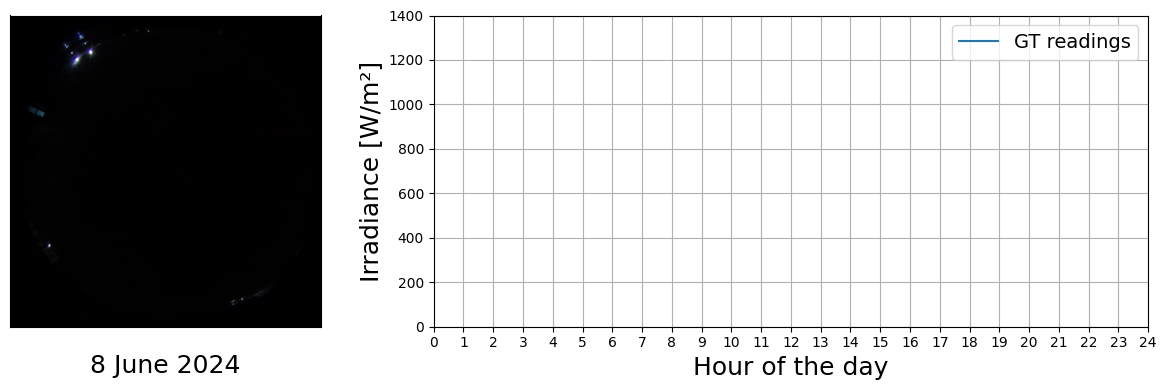

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 2]})

images_plotted = ax[0].imshow(np.asarray(Image.open(image_list[0]))[:, 254:-254])
ax[0].set_xticks([], [])
ax[0].set_yticks([], [])
ax[0].set_xlabel('8 June 2024', fontsize=18, labelpad=20)

lines_plotted = ax[1].plot([], label='GT readings')
ax[1].set_ylabel('Irradiance [W/m²]', fontsize=18)
ax[1].grid(True)
ax[1].set_ylim(0, 1400)
ax[1].set_xlim(0, len(irradiance))
ax[1].set_xticks(np.arange(0, len(irradiance)+1, 60), np.arange(0, 25, 1));
ax[1].set_xlabel('Hour of the day', fontsize=18)
# ax[1].text(25, 1340, '8 June 2024', ha='left', va='top', fontsize=18)

line_plotted = lines_plotted[0]

plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()

factor = 6


def animate(i):
    images_plotted.set_array(np.asarray(Image.open(image_list[i*factor]))[:, 254:-254])
    line_plotted.set_data((np.arange(i*factor), irradiance[:i*factor]))
    return images_plotted, line_plotted


ani = animation.FuncAnimation(fig, animate, repeat=True, frames=len(irradiance)//factor, interval=50)

# To save the animation using Pillow as a gif
writer = animation.PillowWriter(fps=60, metadata=dict(artist='Me'), bitrate=50000)
ani.save('08_06_2024_Modena.gif', writer=writer)

# plt.show()